## AI-Powered Climate Smart Farm Advisor

### Project Information
The **AI-Powered Climate Smart Farm Advisor** is a Machine Learning-based agricultural decision support system that helps farmers make informed decisions. It provides recommendations for crop selection, yield prediction, irrigation scheduling, fertilizer application, disease risk assessment, sowing risk prediction, and Minimum Support Price (MSP) using agricultural and weather datasets.

### Domain
**Agriculture | Artificial Intelligence | Machine Learning | Data Science**

### Industry
**Agricultural Technology (AgriTech)**, focusing on data-driven farming solutions to improve productivity, optimize resource utilization, and promote sustainable agriculture.

### Problem Statement
Farmers face challenges such as unpredictable weather, climate change, water scarcity, and limited access to personalized agricultural recommendations. This project addresses these issues by integrating multiple Machine Learning models into a single intelligent system that provides accurate, data-driven farming recommendations.

In [1]:
!pip install sqlalchemy
!pip install pymysql

In [2]:
# Required Libraries
# ============================================

#data loading into datbase
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.6f}".format)

## 0. Data

The project uses multiple agricultural datasets covering crop recommendation, yield prediction, fertilizer recommendation, irrigation scheduling, disease risk prediction, sowing risk prediction, weather conditions, and Minimum Support Price (MSP). These datasets are integrated to build an AI-powered climate-smart farming advisory system.

### Source

- data.gov.in
- Open-Meteo Weather API
- Soil Grids API

### A) Load datasets into Database

In [3]:
url = URL.create(
    "mysql+pymysql",
    username="root",
    password="root1234",
    host="localhost",
    port=3306,
    database="agri")
engine = create_engine(url)

In [4]:
try:
    with engine.connect() as conn:
        print("Connected successfully!")
except Exception as e:
    print(e)

Connected successfully!


In [5]:
# ============================================
# Read Datasets
# ============================================

yield_df = pd.read_csv(r"C:\Users\malle\OneDrive\Desktop\ML-Project\Data\Yield_dataset.csv")

In [6]:
yield_df.to_sql("yield_data", con= engine,if_exists="replace",index=False)

15277

### B) Loading dataset from Database

In [7]:
yield_df = pd.read_sql(
    "SELECT * FROM yield_data",
    con=engine
)

In [8]:
yield_df

,State_Name,District_Name,Latitude,Longitude,Year,Season,Crop,Area,Production,Mean_Temperature,...,ET0,Soil_Moisture,Soil_Temperature,Soil_pH,Organic_Carbon,Clay,Sand,Silt,Elevation,Yield
0,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Arhar/Tur,21400.000000,2600.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,0.121495
1,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Bajra,1400.000000,500.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,0.357143
2,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Castor seed,1000.000000,100.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,0.100000
3,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Cotton(lint),7300.000000,9400.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,1.287671
4,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Dry chillies,3700.000000,7100.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,1.918919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15272,Telangana,WARANGAL,17.982064,79.597095,2014,Rabi,Sunflower,21.000000,30.000000,24.317609,...,3.740870,0.257793,24.853261,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,1.428571
15273,Telangana,WARANGAL,17.982064,79.597095,2014,Rabi,Sweet potato,42.000000,326.000000,24.317609,...,3.740870,0.257793,24.853261,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,7.761905
15274,Telangana,WARANGAL,17.982064,79.597095,2014,Rabi,Tobacco,70.000000,137.000000,24.317609,...,3.740870,0.257793,24.853261,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,1.957143
15275,Telangana,WARANGAL,17.982064,79.597095,2014,Rabi,Urad,1494.000000,607.000000,24.317609,...,3.740870,0.257793,24.853261,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,0.406292


### C) Dataset Description

#### Yield Dataset

The Yield Dataset is used to predict the expected crop yield based on geographical location, weather conditions, soil properties, and cultivation details. It combines agricultural and climatic features to estimate crop productivity.

**Number of Rows:** 15276  
**Number of Columns:** 26

| Column | Description |
|---------|-------------|
| State_Name | Name of the state where the crop was cultivated. |
| District_Name | Name of the district where the crop was cultivated. |
| Latitude | Latitude of the cultivation location. |
| Longitude | Longitude of the cultivation location. |
| Year | Year of cultivation. |
| Season | Cropping season (Kharif, Rabi, etc.). |
| Crop | Name of the cultivated crop. |
| Area | Total cultivated area (hectares). |
| Production | Total crop production (tonnes). |
| Mean_Temperature | Average temperature during cultivation. |
| Max_Temperature | Maximum recorded temperature. |
| Min_Temperature | Minimum recorded temperature. |
| Precipitation | Total rainfall received during cultivation. |
| Shortwave_Radiation | Solar radiation received by the crop. |
| Wind_Speed | Average wind speed. |
| Relative_Humidity | Average relative humidity. |
| ET0 | Reference evapotranspiration. |
| Soil_Moisture | Soil moisture content. |
| Soil_Temperature | Average soil temperature. |
| Soil_pH | Soil acidity or alkalinity. |
| Organic_Carbon | Organic carbon present in the soil. |
| Clay | Clay percentage in the soil. |
| Sand | Sand percentage in the soil. |
| Silt | Silt percentage in the soil. |
| Elevation | Elevation above sea level (meters). |
| Yield | Crop yield per hectare. |

**Target Variable:** **Yield**

---

In [9]:
yield_df.shape

(15277, 26)

In [10]:
yield_df.head()

,State_Name,District_Name,Latitude,Longitude,Year,Season,Crop,Area,Production,Mean_Temperature,...,ET0,Soil_Moisture,Soil_Temperature,Soil_pH,Organic_Carbon,Clay,Sand,Silt,Elevation,Yield
0,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Arhar/Tur,21400.000000,2600.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,0.121495
1,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Bajra,1400.000000,500.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,0.357143
2,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Castor seed,1000.000000,100.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,0.100000
3,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Cotton(lint),7300.000000,9400.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,1.287671
4,Andhra Pradesh,ANANTAPUR,14.678322,77.606504,1997,Kharif,Dry chillies,3700.000000,7100.000000,26.702157,...,5.643595,0.153111,30.435948,0.710000,1.640000,3.010000,4.610000,2.380000,349.000000,1.918919


In [11]:
yield_df.tail()

,State_Name,District_Name,Latitude,Longitude,Year,Season,Crop,Area,Production,Mean_Temperature,...,ET0,Soil_Moisture,Soil_Temperature,Soil_pH,Organic_Carbon,Clay,Sand,Silt,Elevation,Yield
15272,Telangana,WARANGAL,17.982064,79.597095,2014,Rabi,Sunflower,21.000000,30.000000,24.317609,...,3.740870,0.257793,24.853261,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,1.428571
15273,Telangana,WARANGAL,17.982064,79.597095,2014,Rabi,Sweet potato,42.000000,326.000000,24.317609,...,3.740870,0.257793,24.853261,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,7.761905
15274,Telangana,WARANGAL,17.982064,79.597095,2014,Rabi,Tobacco,70.000000,137.000000,24.317609,...,3.740870,0.257793,24.853261,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,1.957143
15275,Telangana,WARANGAL,17.982064,79.597095,2014,Rabi,Urad,1494.000000,607.000000,24.317609,...,3.740870,0.257793,24.853261,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,0.406292
15276,Telangana,WARANGAL,17.982064,79.597095,2014,Whole Year,Coriander,38.000000,9.000000,27.388219,...,4.664795,0.227118,28.249315,0.690000,3.920000,3.350000,3.480000,3.170000,271.000000,0.236842


In [12]:
yields = yield_df.copy()

In [13]:
# Convert Column Names to Lowercase
yields.columns = yields.columns.str.lower().str.strip()

In [14]:
# Rename columns in Yield Dataset
yields.rename(columns={
    "state_name": "state",
    "district_name": "district"
}, inplace=True)

In [15]:
cat_cols = yields.select_dtypes(include=["object", "string"]).columns
yields[cat_cols] = yields[cat_cols].apply(
    lambda col: col.str.lower().str.strip()
)

- Converted to lowercase and removed extra spaces

## 1. Data Validation

### A) Validation for categorical columns data

In [16]:
for col in cat_cols:
    print(f"\n{col}")
    print(yields[col].unique()) 


state
['andhra pradesh' 'telangana']

district
['anantapur' 'chittoor' 'east godavari' 'guntur' 'kadapa' 'krishna'
 'kurnool' 'prakasam' 'spsr nellore' 'srikakulam' 'visakhapatanam'
 'vizianagaram' 'west godavari' 'adilabad' 'hyderabad' 'karimnagar'
 'khammam' 'mahbubnagar' 'medak' 'nalgonda' 'nizamabad' 'rangareddi'
 'warangal']

season
['kharif' 'rabi' 'whole year']

crop
['arhar/tur' 'bajra' 'castor seed' 'cotton(lint)' 'dry chillies'
 'groundnut' 'horse-gram' 'jowar' 'korra' 'maize' 'moong(green gram)'
 'other kharif pulses' 'ragi' 'rice' 'sugarcane' 'sunflower' 'tobacco'
 'gram' 'wheat' 'masoor' 'sesamum' 'urad' 'linseed' 'safflower' 'onion'
 'other misc. pulses' 'samai' 'small millets' 'arecanut' 'banana'
 'coconut' 'coriander' 'potato' 'sweet potato' 'turmeric'
 'other  rabi pulses' 'soyabean' 'beans & mutter(vegetable)' 'bhindi'
 'brinjal' 'citrus fruit' 'cucumber' 'grapes' 'mango' 'orange'
 'other fibres' 'other fresh fruits' 'other vegetables' 'papaya'
 'pome fruit' 'tomato'

In [17]:
# correcting the spell mistake
yields["district"] = yields["district"].replace({
    "visakhapatanam": "visakhapatnam"
})

yields["crop"] = yields["crop"].replace({
    "rapeseed &mustard": "rapeseed & mustard",
    "other  rabi pulses": "other rabi pulses",
    "peas  (vegetable)": "peas (vegetable)",
    "pome granet": "pomegranate",
    "cashewnut": "cashew nut",
    "beans & mutter(vegetable)": "beans & matar (vegetable)"
})

### B) Data Validation for Numerical Columns

In [18]:
yields.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15277 entries, 0 to 15276
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                15277 non-null  object 
 1   district             15277 non-null  object 
 2   latitude             15277 non-null  float64
 3   longitude            15277 non-null  float64
 4   year                 15277 non-null  int64  
 5   season               15277 non-null  object 
 6   crop                 15277 non-null  object 
 7   area                 15277 non-null  float64
 8   production           15152 non-null  float64
 9   mean_temperature     15277 non-null  float64
 10  max_temperature      15277 non-null  float64
 11  min_temperature      15277 non-null  float64
 12  precipitation        15277 non-null  float64
 13  shortwave_radiation  15277 non-null  float64
 14  wind_speed           15277 non-null  float64
 15  relative_humidity    15277 non-null 

- The data types for the columns are correct so there is no need of change

In [19]:
yields.isna().sum()

state                    0
district                 0
latitude                 0
longitude                0
year                     0
season                   0
crop                     0
area                     0
production             125
mean_temperature         0
max_temperature          0
min_temperature          0
precipitation            0
shortwave_radiation      0
wind_speed               0
relative_humidity        0
et0                      0
soil_moisture            0
soil_temperature         0
soil_ph                  0
organic_carbon           0
clay                     0
sand                     0
silt                     0
elevation                0
yield                  125
dtype: int64

- Found Null Values in yield dataset for the columns of production and yield

In [20]:
yields.duplicated().sum()

np.int64(0)

#### **Insights:**
- no duplicate data found

In [21]:
yields["soil_ph"] = yields["soil_ph"]*10

## 2. EDA

In [22]:
yields["yield"].describe()

count   15152.000000
mean      160.479859
std      1380.089533
min         0.000000
25%         0.500000
50%         1.200000
75%         3.651270
max     33089.005477
Name: yield, dtype: float64

In [23]:
# Display all rows having the coconut as crop
yields[yields["crop"] == "coconut"]

,state,district,latitude,longitude,year,season,crop,area,production,mean_temperature,...,et0,soil_moisture,soil_temperature,soil_ph,organic_carbon,clay,sand,silt,elevation,yield
126,andhra pradesh,anantapur,14.678322,77.606504,2000,whole year,coconut,908.000000,3896970.000000,26.522541,...,5.274590,0.175648,29.287705,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,4291.817181
172,andhra pradesh,anantapur,14.678322,77.606504,2001,whole year,coconut,851.000000,3053700.000000,26.603370,...,5.539342,0.151710,30.088767,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,3588.366627
219,andhra pradesh,anantapur,14.678322,77.606504,2002,whole year,coconut,869.000000,3691149.000000,27.092493,...,5.668767,0.138734,30.263836,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,4247.582278
276,andhra pradesh,anantapur,14.678322,77.606504,2003,whole year,coconut,839.000000,3285828.000000,27.659562,...,5.848247,0.123433,31.234521,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,3916.362336
325,andhra pradesh,anantapur,14.678322,77.606504,2004,whole year,coconut,837.000000,6413350.000000,26.287049,...,5.419344,0.152383,29.681148,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,7662.305854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14487,telangana,rangareddi,16.934415,77.778834,2008,whole year,coconut,1.000000,9321.000000,25.945383,...,4.783525,0.227984,27.274590,7.000000,1.860000,3.230000,3.610000,3.150000,501.000000,9321.000000
14525,telangana,rangareddi,16.934415,77.778834,2009,whole year,coconut,2.000000,22344.000000,27.014630,...,5.007945,0.206586,28.435616,7.000000,1.860000,3.230000,3.610000,3.150000,501.000000,11172.000000
14613,telangana,rangareddi,16.934415,77.778834,2011,whole year,coconut,1.000000,14606.000000,26.820712,...,4.881808,0.213441,27.551233,7.000000,1.860000,3.230000,3.610000,3.150000,501.000000,14606.000000
14656,telangana,rangareddi,16.934415,77.778834,2013,whole year,coconut,2.000000,33.000000,26.184548,...,4.619973,0.249926,27.360000,7.000000,1.860000,3.230000,3.610000,3.150000,501.000000,16.500000


In [24]:
# Create a separate dataset for coconut
coconut_df = yields[yields["crop"] == "coconut"].copy()

In [25]:

# Remove coconut records from the yield dataset
yields = yields[yields["crop"] != "coconut"].copy()

In [26]:
print("Yields")
print("rows :",yields.shape[0])
print("columns :",yields.shape[1])

Yields
rows : 15056
columns : 26


In [27]:
#verify
print("Yield Dataset Shape:", yields.shape)
print("Coconut Dataset Shape:", coconut_df.shape)

print("\nYield Dataset Crops:")
print(yields["crop"].unique())

print("\nCoconut Dataset Crops:")
print(coconut_df["crop"].unique())

Yield Dataset Shape: (15056, 26)
Coconut Dataset Shape: (221, 26)

Yield Dataset Crops:
['arhar/tur' 'bajra' 'castor seed' 'cotton(lint)' 'dry chillies'
 'groundnut' 'horse-gram' 'jowar' 'korra' 'maize' 'moong(green gram)'
 'other kharif pulses' 'ragi' 'rice' 'sugarcane' 'sunflower' 'tobacco'
 'gram' 'wheat' 'masoor' 'sesamum' 'urad' 'linseed' 'safflower' 'onion'
 'other misc. pulses' 'samai' 'small millets' 'arecanut' 'banana'
 'coriander' 'potato' 'sweet potato' 'turmeric' 'other rabi pulses'
 'soyabean' 'beans & matar (vegetable)' 'bhindi' 'brinjal' 'citrus fruit'
 'cucumber' 'grapes' 'mango' 'orange' 'other fibres' 'other fresh fruits'
 'other vegetables' 'papaya' 'pome fruit' 'tomato' 'rapeseed & mustard'
 'mesta' 'cowpea(lobia)' 'other oilseeds' 'lemon' 'pomegranate' 'sapota'
 'cabbage' 'cashew nut' 'tapioca' 'peas (vegetable)' 'niger seed'
 'bottle gourd' 'dry ginger' 'sannhamp' 'varagu' 'garlic' 'ginger'
 'other dry fruit']

Coconut Dataset Crops:
['coconut']


In [28]:
yields.to_csv(r"C:\Users\malle\OneDrive\Desktop\Agri_Fusion\datasets\yield\Yield_dataset_without_coconut.csv", index=False)
coconut_df.to_csv(r"C:\Users\malle\OneDrive\Desktop\Agri_Fusion\datasets\yield\Coconut_dataset.csv", index=False)

### **2.1 Yield dataset**

#### Target Variable Analysis

The target variable for this project is **Yield**, which represents the agricultural productivity obtained per unit area. Understanding the distribution of the target variable is essential because it helps identify the range of values, central tendency, skewness, and potential outliers before building a regression model.

In [29]:
yields["yield"].describe()

count   14931.000000
mean        5.759601
std        15.209774
min         0.000000
25%         0.492782
50%         1.166989
75%         3.458576
max       134.142636
Name: yield, dtype: float64

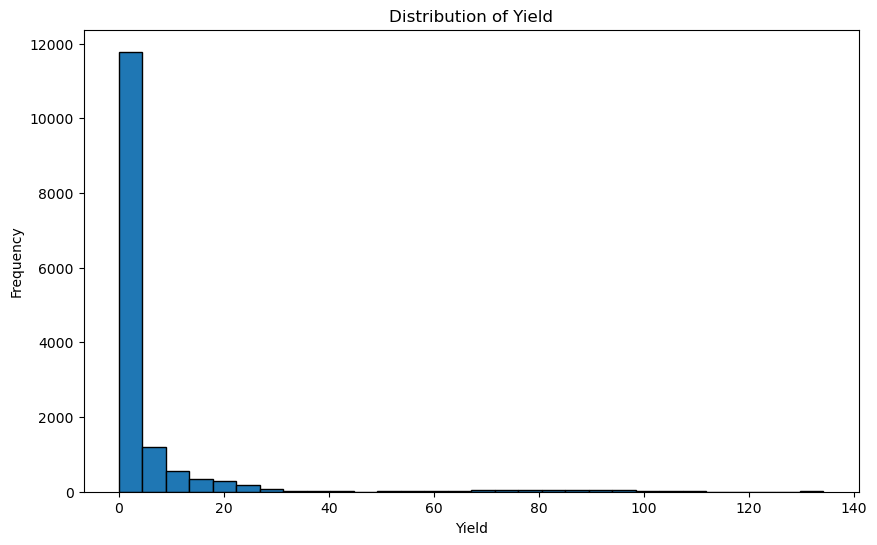

In [30]:
plt.figure(figsize=(10,6))

plt.hist(yields["yield"], bins=30, edgecolor="black")

plt.title("Distribution of Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.show()

#### **Insights:**
- The majority of crops produced relatively low yields, while only a small number of crops achieved very high yields.

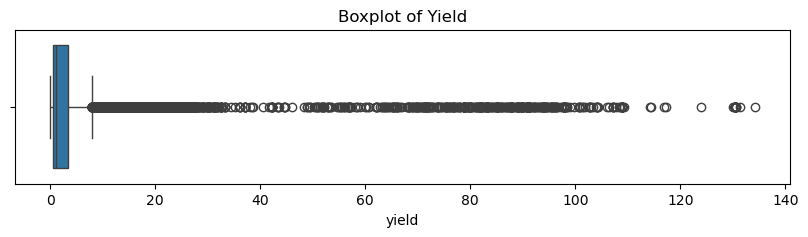

In [31]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=yields["yield"]
)

plt.title("Boxplot of Yield")

plt.show()

#### **Insights:**
- most crops produce lower yields.
- few crops produce high yields.
- The box plot shows the presence of many high-value outliers as the frequency of the lower yield is high whereas only few crops produce very high yields.

### 2.1.1 Univariate Analysis

In [32]:
# Display all numerical columns
num_cols = yields.select_dtypes(include=["number"]).columns.tolist()

print(num_cols)

['latitude', 'longitude', 'year', 'area', 'production', 'mean_temperature', 'max_temperature', 'min_temperature', 'precipitation', 'shortwave_radiation', 'wind_speed', 'relative_humidity', 'et0', 'soil_moisture', 'soil_temperature', 'soil_ph', 'organic_carbon', 'clay', 'sand', 'silt', 'elevation', 'yield']


#### A) Area Distribution:

The **Area** column represents the total cultivated land area used for growing a particular crop. Analyzing its distribution helps identify the range of cultivated land, the presence of small and large farms, and potential outliers.

In [33]:
yields["area"].describe()

count    15056.000000
mean     14051.738111
std      42843.285639
min          1.000000
25%        192.000000
50%       1302.000000
75%       7942.500000
max     877029.000000
Name: area, dtype: float64

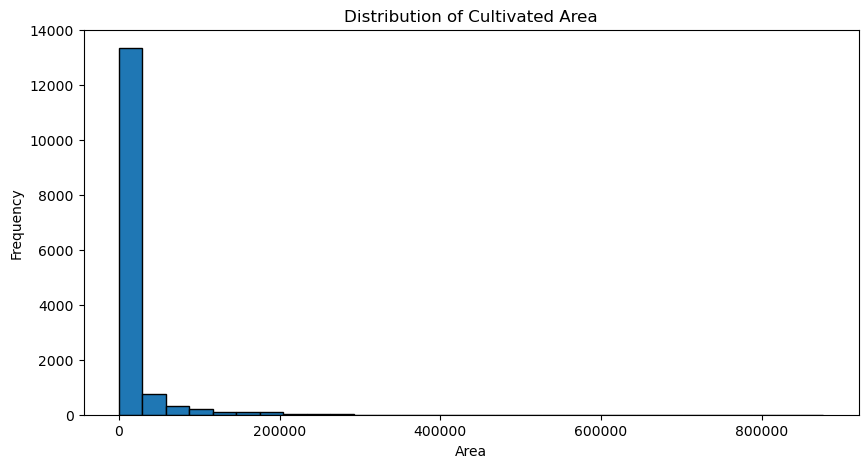

In [34]:
plt.figure(figsize=(10,5))

plt.hist(yields["area"], bins=30, edgecolor="black")

plt.title("Distribution of Cultivated Area")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.show()

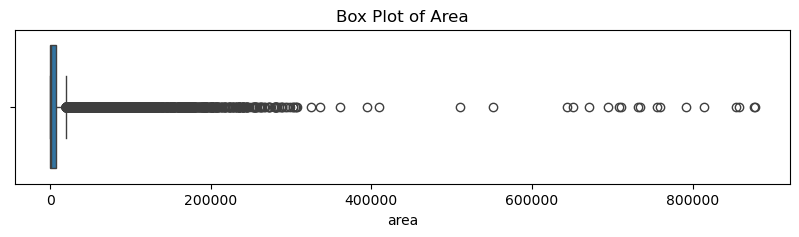

In [35]:
plt.figure(figsize=(10,2))

sns.boxplot(x=yields["area"])

plt.title("Box Plot of Area")

plt.show()

#### **Insights:**
- The dataset contains several high-value observations (potential outliers).
- Most observations are concentrated at lower cultivated area values, while highly cultivated area observations are less frequent.

#### B) Crop Distribution
The **Crop** column represents the type of agricultural crop cultivated in each observation. It is a categorical feature that contains the names of different crops grown across various districts, seasons, and years.

In [36]:
yields["crop"].value_counts().head(20)

crop
rice                 794
maize                762
groundnut            760
dry chillies         720
jowar                714
moong(green gram)    711
urad                 695
sesamum              671
arhar/tur            558
onion                549
horse-gram           521
bajra                494
ragi                 447
sunflower            439
cotton(lint)         398
tobacco              367
gram                 365
sugarcane            360
castor seed          343
turmeric             299
Name: count, dtype: int64

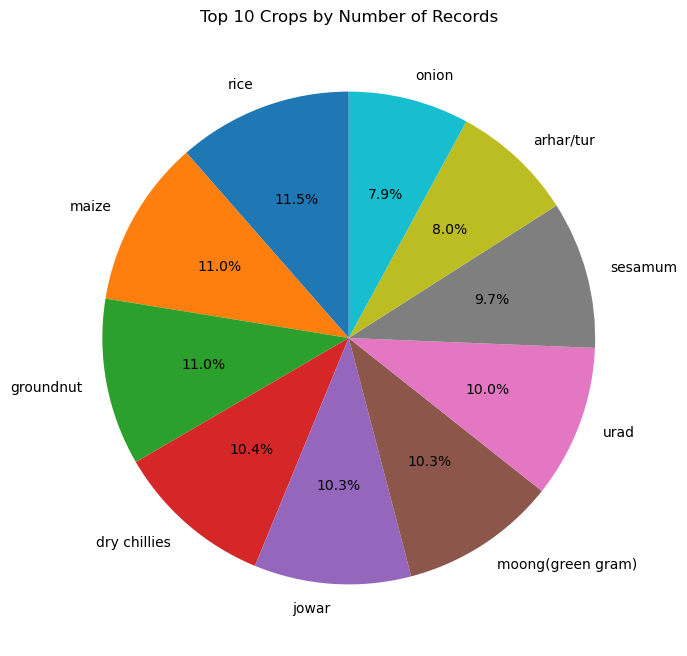

In [37]:
# Get the top 10 most frequent crops
top10_crops = yields["crop"].value_counts().head(10)

# Plot pie chart
plt.figure(figsize=(8,8))

plt.pie(
    top10_crops,
    labels=top10_crops.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Crops by Number of Records")

plt.show()

#### **Insights:**
- rice is more cultivated crop followed by groundnut and maize

#### C) Season Distribution
The **Season** column represents the agricultural growing season during which a crop was cultivated. Different seasons have distinct climatic conditions, including variations in rainfall, temperature, humidity, and sunlight, all of which influence crop growth and productivity.

In [38]:
yields["season"].value_counts()

season
kharif        6597
rabi          5714
whole year    2745
Name: count, dtype: int64

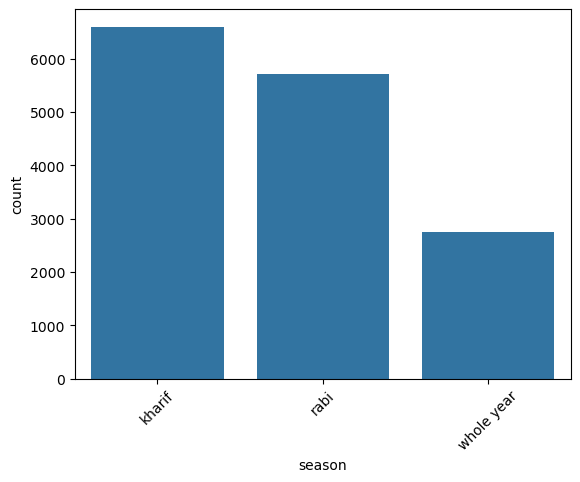

In [39]:
sns.countplot(data=yields, x="season")

plt.xticks(rotation=45)

plt.show()

#### **Insights:**
- The Crops are mostly cultivated in kharif(june to october) and rabi (October to April)

#### D) Rainfall Distribution
The **Precipitation** column represents the total amount of rainfall received during the crop growing season at a particular location. Rainfall is one of the most important climatic factors affecting agricultural production, as it directly influences soil moisture, crop growth, and overall yield.


In [40]:
yields["precipitation"].describe()

count   15056.000000
mean      587.397984
std       365.463493
min        11.980000
25%       257.270000
50%       597.490000
75%       820.440000
max      1981.680000
Name: precipitation, dtype: float64

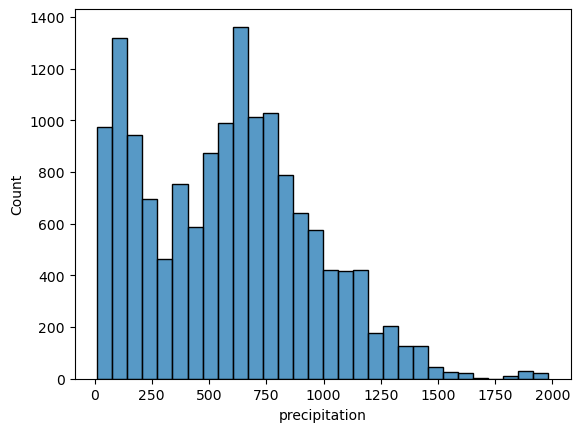

In [41]:
sns.histplot(yields["precipitation"], bins=30)

plt.show()

#### **Insights:**
- most crops needed the rainfall on average 590 mm

#### E) Temperature Distribution
The **Mean Temperature** column represents the average air temperature recorded during the crop growing season. Temperature is a critical climatic factor that influences seed germination, plant growth, flowering, and crop maturity. Both excessively high and low temperatures can negatively affect crop development and reduce agricultural productivity.

In [42]:
yields["mean_temperature"].describe()

count   15056.000000
mean       26.183983
std         2.046790
min        20.163913
25%        24.615870
50%        26.547890
75%        27.817320
max        30.236536
Name: mean_temperature, dtype: float64

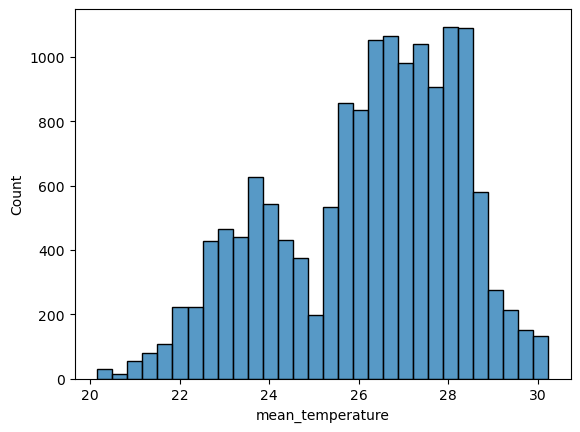

In [43]:
sns.histplot(yields["mean_temperature"], bins=30)

plt.show()

#### **Insights:**
- The average temperature for the crops needed are on about around 26 to 28 degree celcius

### F) Correlation Analysis

A correlation matrix measures the strength and direction of the linear relationship between numerical variables. Correlation values range from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No linear correlation
- **-1** → Perfect negative correlation

This analysis helps identify variables that are strongly associated with the target variable (Yield).

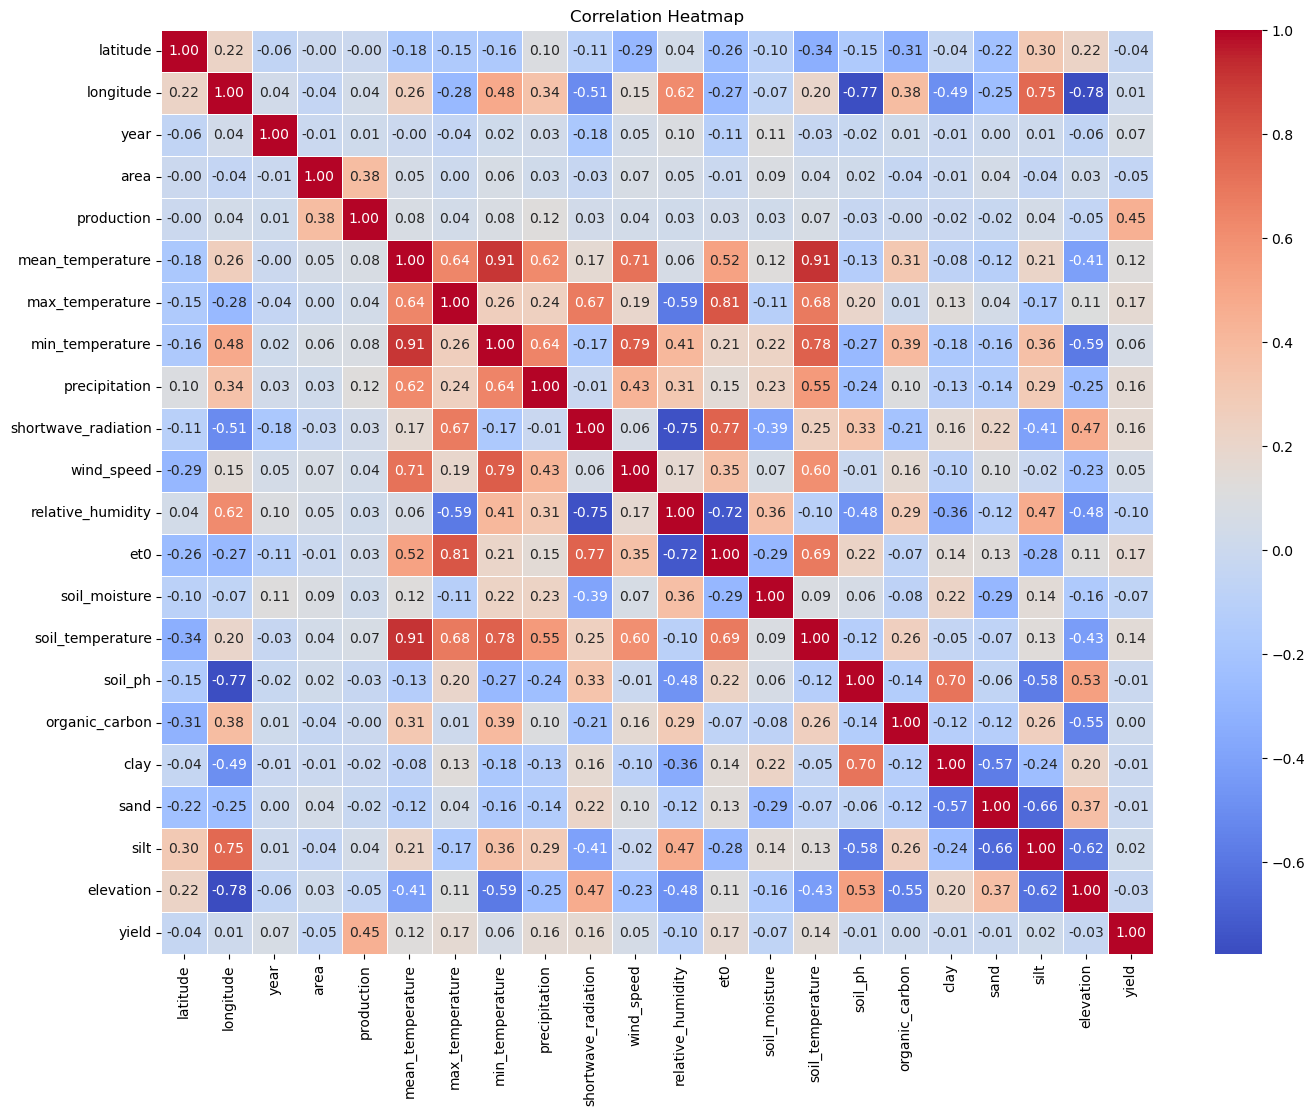

In [44]:
plt.figure(figsize=(16,12))

sns.heatmap(
    yields.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

#### **Insights:**
- Production has the highest positive correlation with yield (0.45), indicating a moderate positive linear relationship.
- Maximum temperature, ET₀, precipitation, and shortwave radiation show weak positive relationships with yield.
- **Crop yield does not have a strong linear relationship with most individual features. This suggests that yield is influenced by multiple factors together rather than by a single variable.**
- Mean temperature and maximum temperature are highly positively correlated, indicating that they provide similar information.
- Mean temperature and soil temperature are highly positively correlated, indicating that both variables carry similar information.
- Relative humidity and ET₀ have a strong negative correlation, indicating that ET₀ generally decreases as relative humidity increases.

### 2.1.2 Bivariate Analysis

#### A) Crop vs Average Yield:
This analysis examines the average crop yield for each crop type in the dataset.
Comparing the average yield across crops helps identify the most productive crops and those with relatively lower productivity.

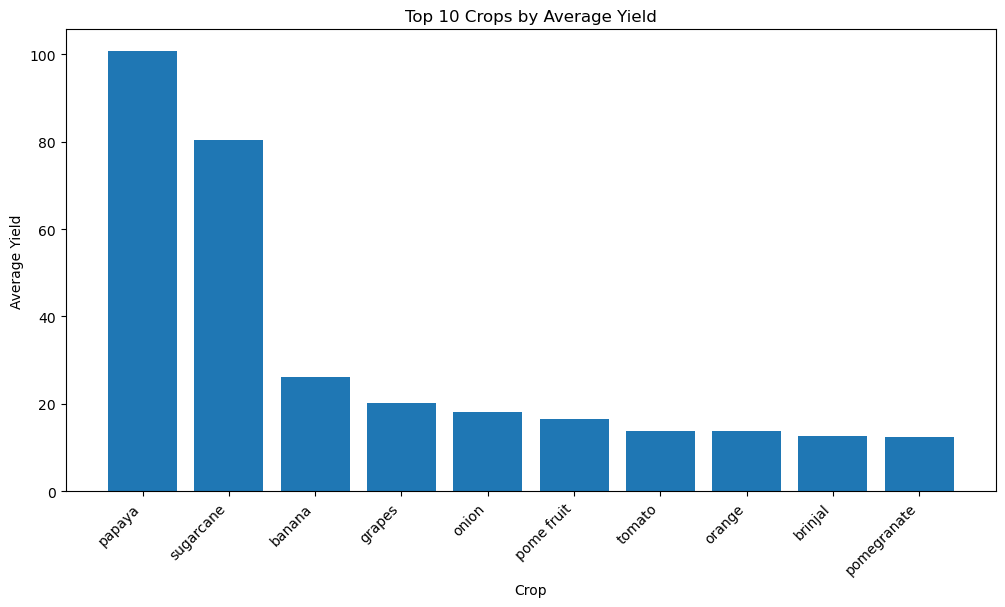

In [45]:
# Top 10 crops with the highest average yield
crop_yield = (
    yields.groupby("crop")["yield"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    crop_yield.index,
    crop_yield.values
)

plt.title("Top 10 Crops by Average Yield")
plt.xlabel("Crop")
plt.ylabel("Average Yield")

plt.xticks(rotation=45, ha="right")

plt.show()

#### **Insights:**
- papaya is producing more yield compared to other crops followed by sugarcane

#### B)Season vs Average Yield:
This analysis examines the **average crop yield across different agricultural seasons**. Seasonal conditions such as rainfall, temperature, humidity, and sunlight vary throughout the year and have a significant influence on crop growth and productivity.

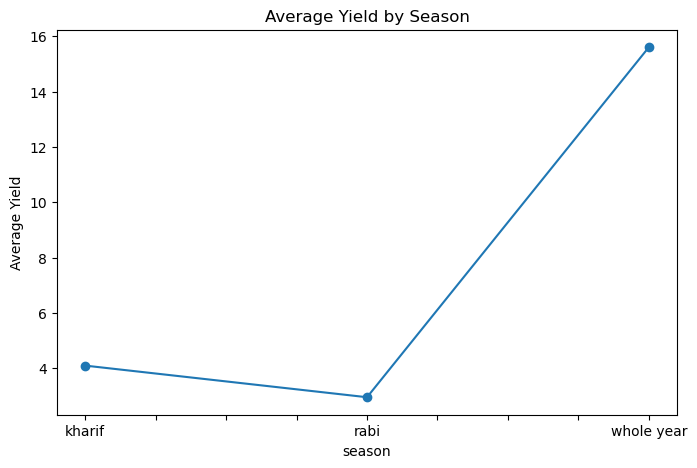

In [46]:
avg_yield = yields.groupby("season")["yield"].mean()

plt.figure(figsize=(8,5))

avg_yield.plot(marker="o")

plt.title("Average Yield by Season")
plt.ylabel("Average Yield")

plt.show()

#### **Insights:**
- In AP,Telenaga most crops cultivated are which produces yield Throughout the year.

#### D) Yield vs Rainfall:
This analysis examines the **average rainfall received by different crops** during their growing periods. Rainfall is one of the most important climatic factors influencing crop growth, soil moisture, and overall agricultural productivity.

Different crops have different water requirements. By comparing the average rainfall associated with each crop, we can identify crops that are generally cultivated in high-rainfall regions and those adapted to relatively drier conditions.

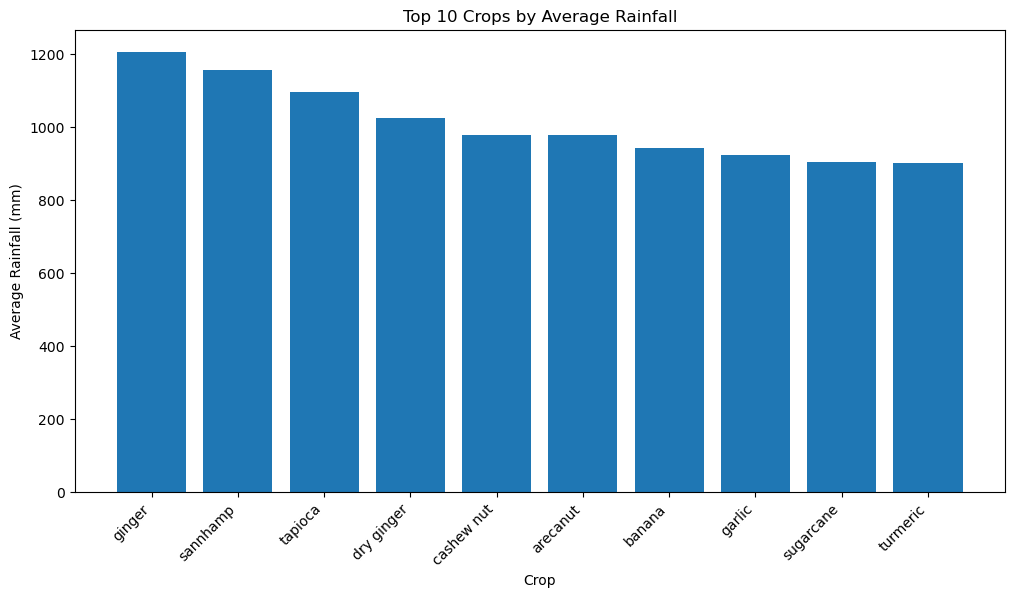

In [47]:
# Top 10 crops by average rainfall
rainfall_crop = (
    yields.groupby("crop")["precipitation"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    rainfall_crop.index,
    rainfall_crop.values
)

plt.title("Top 10 Crops by Average Rainfall")
plt.xlabel("Crop")
plt.ylabel("Average Rainfall (mm)")

plt.xticks(rotation=45, ha="right")

plt.show()

#### **Insights:**
- the top 10 crops shown above needed most rainfall which can be interpreted as the rainfall increases the yield increases.

#### E)Crop vs Total Production

This analysis examines the **total agricultural production** for different crop types in the dataset. Production represents the total quantity of crop harvested and is influenced by factors such as cultivated area, yield, climatic conditions, and farming practices.

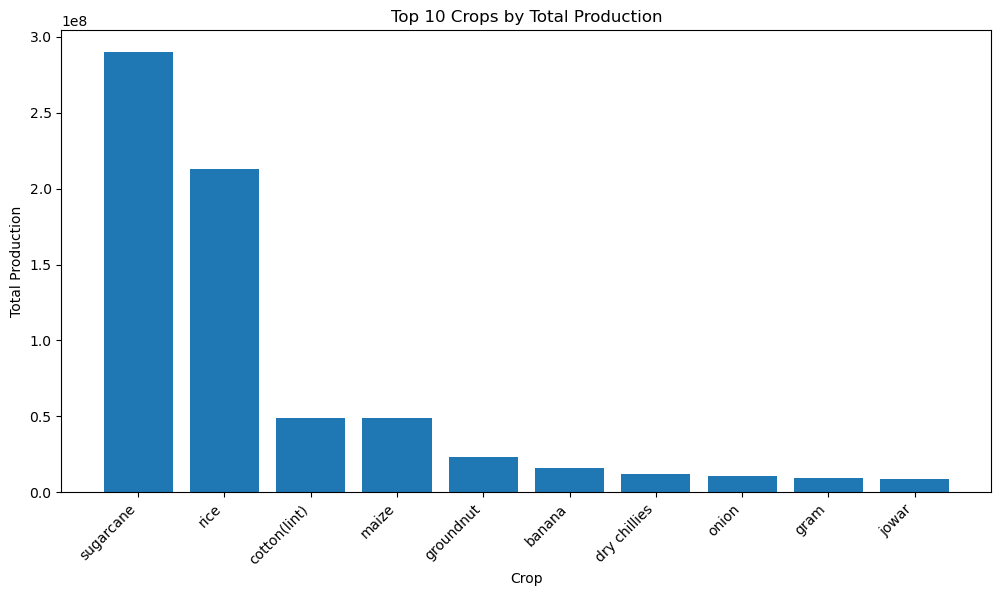

In [48]:
# Top 10 crops by total production
crop_production = (
    yields.groupby("crop")["production"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    crop_production.index,
    crop_production.values
)

plt.title("Top 10 Crops by Total Production")
plt.xlabel("Crop")
plt.ylabel("Total Production")

plt.xticks(rotation=45, ha="right")

plt.show()

#### **Insights:**
- Sugarcane Production is high compared to other crops followed by rice.

#### F) Temperature vs Yield
This analysis examines the relationship between **Mean Temperature** and **Crop Yield**. Temperature is one of the most important climatic factors affecting agricultural productivity, as it influences seed germination, plant growth, flowering, and crop maturity.

Different crops have different optimum temperature ranges for growth. Extremely low or high temperatures can reduce crop productivity, while moderate temperatures often promote healthy plant development.

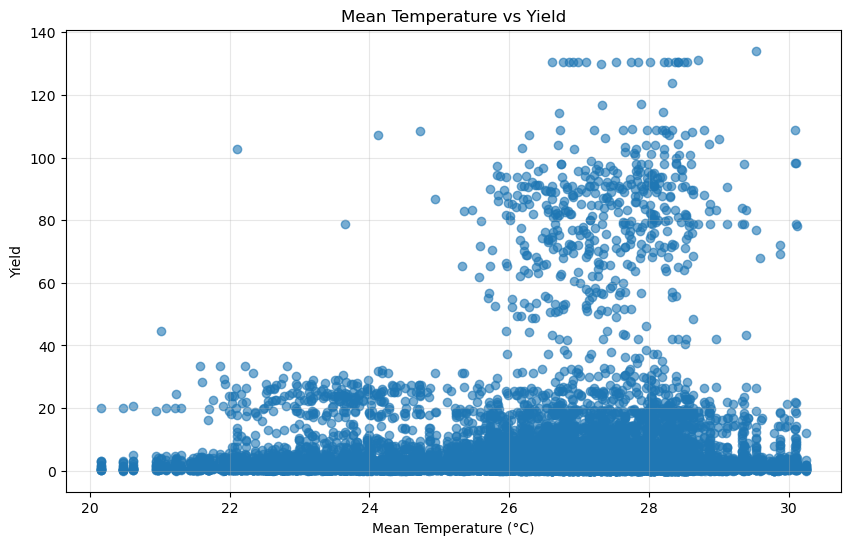

In [49]:
plt.figure(figsize=(10,6))

plt.scatter(
    yields["mean_temperature"],
    yields["yield"],
    alpha=0.6
)

plt.title("Mean Temperature vs Yield")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Yield")

plt.grid(alpha=0.3)

plt.show()

#### **Insights:**
- Most of the high-yield observations are concentrated between 27°C and 29°C.
- Lower yield values are observed across almost the entire temperature range, indicating that temperature alone does not determine crop yield.

**Average Yield by State**

In [50]:
yields.groupby("state")["yield"].mean().sort_values(ascending=False)

state
andhra pradesh   6.303188
telangana        4.837887
Name: yield, dtype: float64

#### **Insights:**
- AP has high average yield than telangana in between 1997 to 2014.

**Average Yield by District**

In [51]:
yields.groupby("district")["yield"].mean().sort_values(ascending=False)

district
krishna         7.508641
west godavari   6.987416
guntur          6.891890
chittoor        6.724326
spsr nellore    6.673797
kadapa          6.532159
anantapur       6.395199
kurnool         6.366995
east godavari   6.289228
srikakulam      6.097465
vizianagaram    5.891167
khammam         5.790967
prakasam        5.434966
rangareddi      5.401882
nalgonda        5.344412
nizamabad       5.233881
karimnagar      5.117501
medak           4.912572
visakhapatnam   4.706184
mahbubnagar     4.187356
adilabad        4.098430
warangal        3.548021
hyderabad       1.969792
Name: yield, dtype: float64

#### **Insights:**
- Krishna has highest yield producer while hyderabad is the lowest yield producer among all districts

### 2.1.3 Multi-Variate annalysis

#### A) Yield vs Temperature vs crop

<Figure size 1000x600 with 0 Axes>

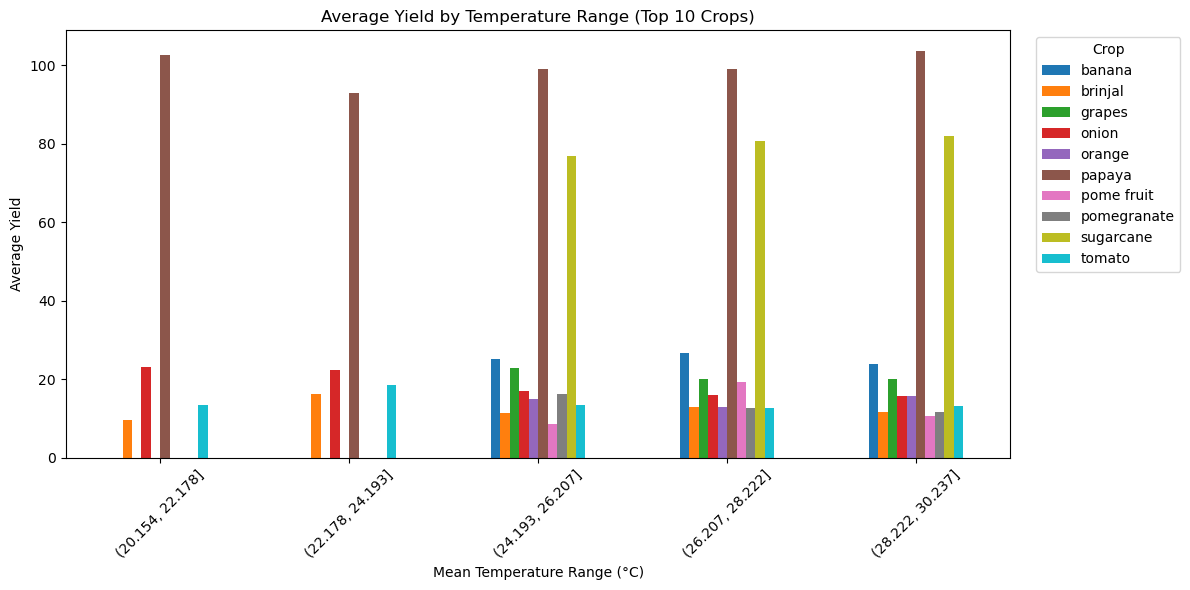

In [52]:
# Create temperature ranges
yields["temp_range"] = pd.cut(
    yields["mean_temperature"],
    bins=5
)

# Find the top 10 crops by average yield
top10_crops = (
    yields.groupby("crop")["yield"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Keep only the top 10 crops
temp_crop = (
    yields[yields["crop"].isin(top10_crops)]
    .groupby(["temp_range", "crop"])["yield"]
    .mean()
    .unstack()
)

# Plot
plt.figure(figsize=(10,6))

temp_crop.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Yield by Temperature Range (Top 10 Crops)")
plt.xlabel("Mean Temperature Range (°C)")
plt.ylabel("Average Yield")

plt.xticks(rotation=45)
plt.legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### **Insights:**
- Papaya produces high average yield regardless of the temperature(20 to 30 degree celcius) compared to other crops.
- Sugarcane,Banana,grapes,orange,pome fruit, and pomegranate needs the temperature between 24 to 30 degree celcius.
- Onion,brinjal,and tomato produces same average yield reagardless of temperature (20 to 30 degree celcius).


#### B) Crop vs Season vs Average Yield

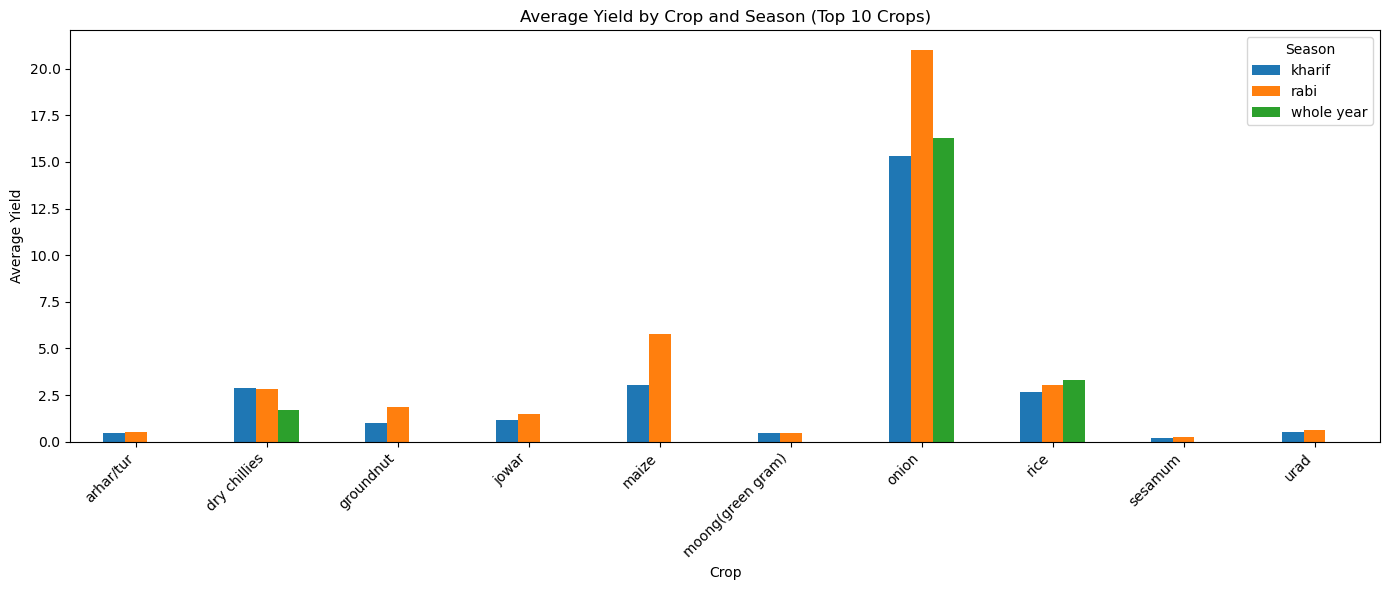

In [53]:
# Select the top 10 crops based on the number of records
top10_crops = yields["crop"].value_counts().head(10).index

# Calculate average yield for each crop-season combination
crop_season = (
    yields[yields["crop"].isin(top10_crops)]
    .groupby(["crop", "season"])["yield"]
    .mean()
    .unstack()
)

# Plot grouped bar chart
crop_season.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Average Yield by Crop and Season (Top 10 Crops)")
plt.xlabel("Crop")
plt.ylabel("Average Yield")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")

plt.tight_layout()
plt.show()

#### **Insights:**
- onion produces high average yield regardless of season compared to other crops.
- maize produces average yield high in rabi compared to kharif.
- rice,dry chillies,onion crops are cultivated throughout the year.

#### C) District vs Crop vs Average Yield

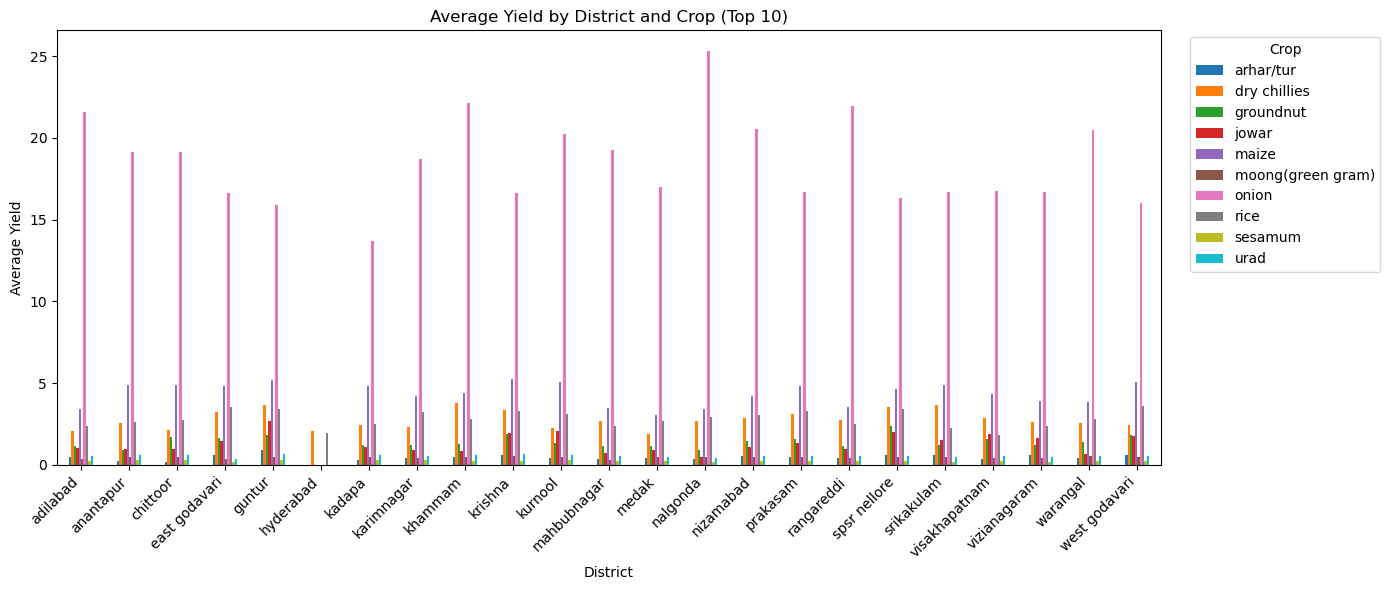

In [54]:
# Top 10 districts based on number of records
top10_districts = yields["district"].value_counts().head(30).index

# Top 10 crops based on number of records
top10_crops = yields["crop"].value_counts().head(10).index

# Average yield by district and crop
district_crop = (
    yields[
        (yields["district"].isin(top10_districts)) &
        (yields["crop"].isin(top10_crops))
    ]
    .groupby(["district", "crop"])["yield"]
    .mean()
    .unstack()
)

# Plot
district_crop.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Average Yield by District and Crop (Top 10)")
plt.xlabel("District")
plt.ylabel("Average Yield")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### **Insights:**
- all most every district other than hyderabad in ap,telangana cultivated onion.
- oninon crop has relatively higher average yield compared to other crops, followed by maize.
- hyderabad mostly cultivates dry chillies and rice.
- other than hyderabad many other districts cultivates maize.

#### D) State × Season x Average Yield

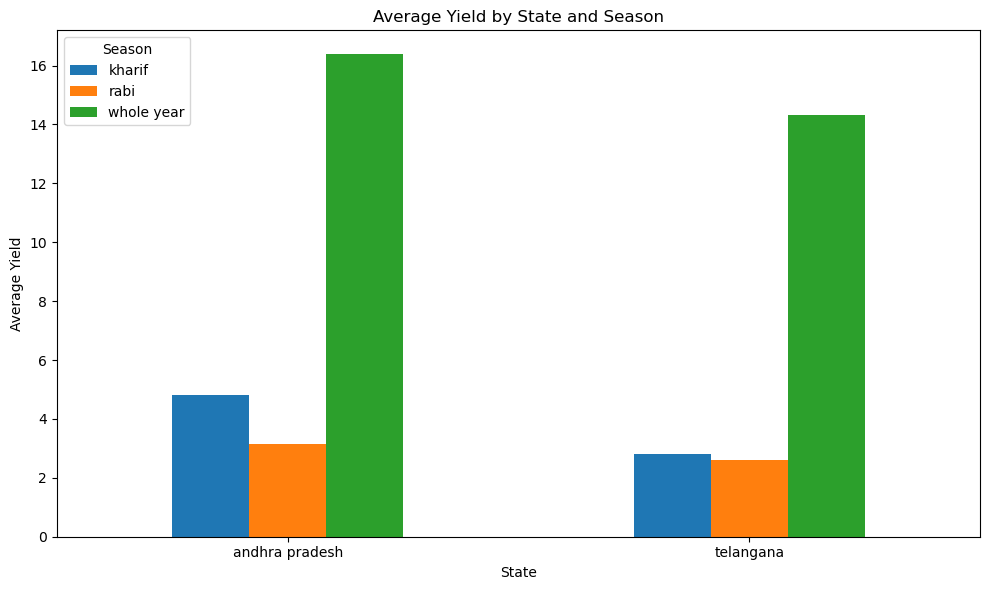

In [55]:
# Calculate average yield by state and season
state_season = (
    yields.groupby(["state", "season"])["yield"]
    .mean()
    .unstack()
)

# Plot grouped bar chart
state_season.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Yield by State and Season")
plt.xlabel("State")
plt.ylabel("Average Yield")

plt.xticks(rotation=0)
plt.legend(title="Season")

plt.tight_layout()
plt.show()

#### **Insights:**
- Andra Pradesh and Telangana cultivates the crops which produces the whole year with high yield compared to season based crops.

#### E) Crop × Year vs Average Yield

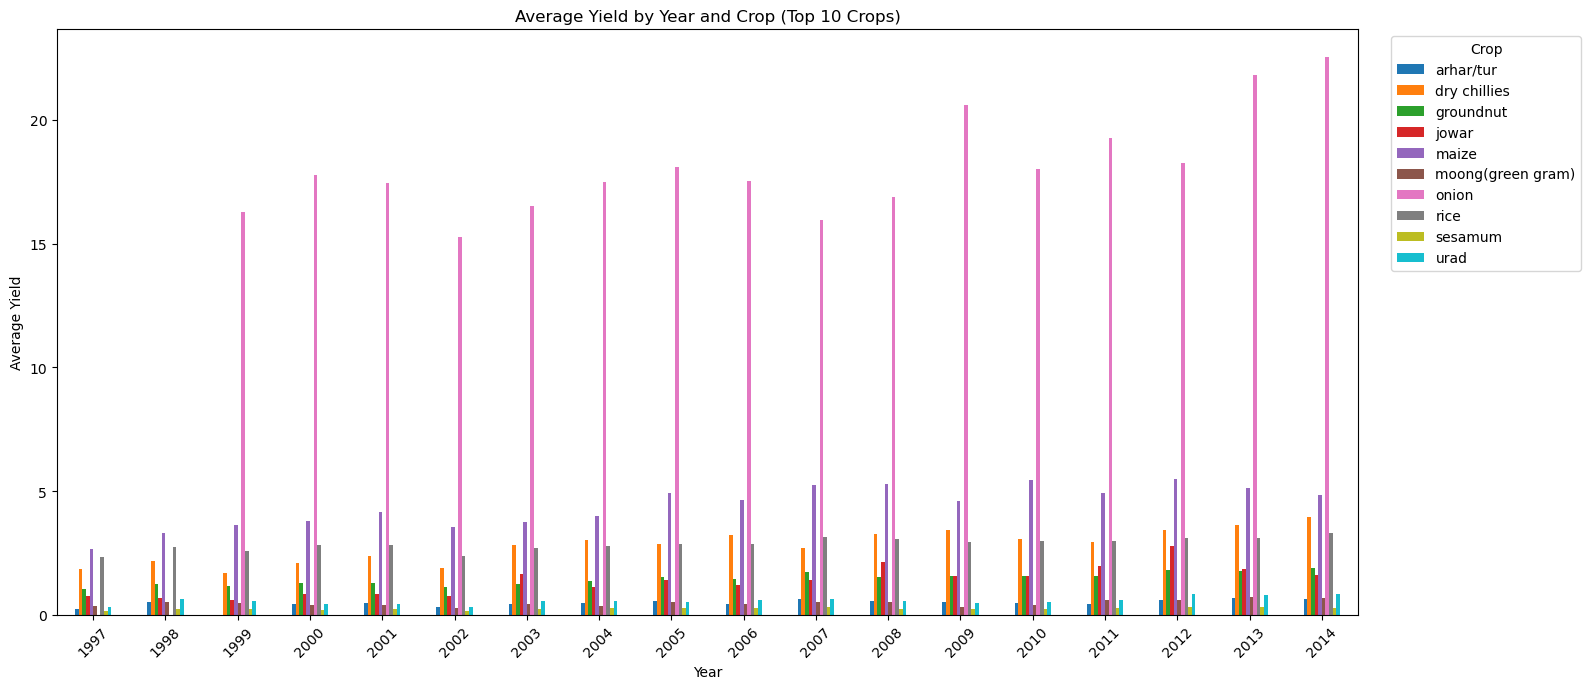

In [56]:
# Top 10 crops based on number of records
top10_crops = yields["crop"].value_counts().head(10).index

# Average yield by year and crop
crop_year = (
    yields[yields["crop"].isin(top10_crops)]
    .groupby(["year", "crop"])["yield"]
    .mean()
    .unstack()
)

# Plot grouped bar chart
crop_year.plot(
    kind="bar",
    figsize=(16,7)
)

plt.title("Average Yield by Year and Crop (Top 10 Crops)")
plt.xlabel("Year")
plt.ylabel("Average Yield")

plt.xticks(rotation=45)
plt.legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### **Insights:**
- Onion yield is producing high yield relatively high compared to other crops in continuous years other than few years in which maize produced more yields when onion is not cultivated.

#### F) Rainfall Range × Crop vs Average Yield

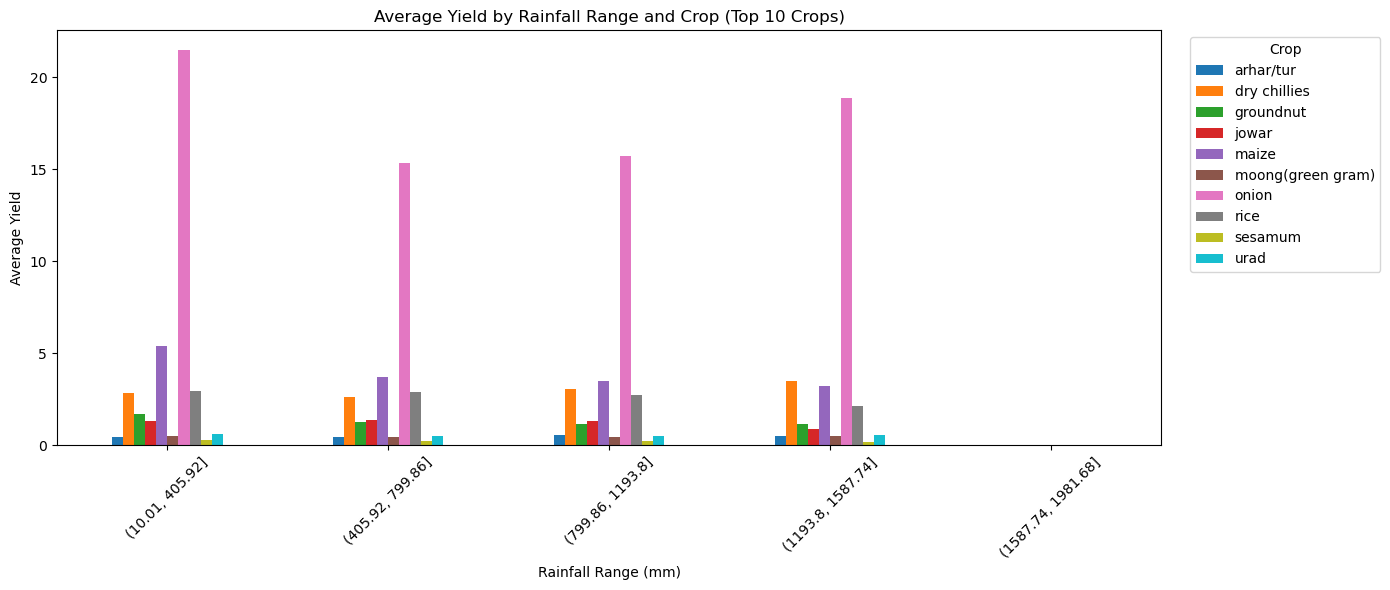

In [57]:
# Create rainfall ranges
yields["rainfall_range"] = pd.cut(
    yields["precipitation"],
    bins=5
)

# Top 10 crops based on number of records
top10_crops = yields["crop"].value_counts().head(10).index

# Calculate average yield for each rainfall range and crop
rainfall_crop = (
    yields[yields["crop"].isin(top10_crops)]
    .groupby(["rainfall_range", "crop"])["yield"]
    .mean()
    .unstack()
)

# Plot grouped bar chart
rainfall_crop.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Average Yield by Rainfall Range and Crop (Top 10 Crops)")
plt.xlabel("Rainfall Range (mm)")
plt.ylabel("Average Yield")

plt.xticks(rotation=45)
plt.legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### **Insights:**
- the onion or any other crops can only produce high yield from 10 mm until the 1500 mm rainfall as the rain increases we might not get the high yield we might even suffer loses.

In [58]:
yields.drop(columns =['temp_range', 'rainfall_range'],inplace = True)

## 3.Predictive Modeling

### 3.0 Pre-Requisites

### 3.0.1 Na and Outliers
Missing values in the production column are filled using the median production of the corresponding state and season group, ensuring missing values are replaced with representative values from the same state and season.

In [59]:
model_df = yields.copy()

In [60]:
model_df["production"].isnull().sum()

np.int64(125)

In [61]:
model_df["yield"].isnull().sum()

np.int64(125)

In [62]:
null_production = model_df[model_df["production"].isna()]
null_production[["state", "district", "year", "season", "crop", "production"]]

,state,district,year,season,crop,production
420,andhra pradesh,anantapur,2007,kharif,moong(green gram),NaN
427,andhra pradesh,anantapur,2007,rabi,horse-gram,NaN
495,andhra pradesh,anantapur,2009,rabi,rapeseed & mustard,NaN
520,andhra pradesh,anantapur,2010,kharif,other kharif pulses,NaN
950,andhra pradesh,chittoor,2001,rabi,wheat,NaN
...,...,...,...,...,...,...
14747,telangana,warangal,1998,rabi,moong(green gram),NaN
14748,telangana,warangal,1998,rabi,other rabi pulses,NaN
14925,telangana,warangal,2003,rabi,other oilseeds,NaN
15073,telangana,warangal,2007,rabi,horse-gram,NaN


- Null values data retrieved

In [63]:
for crop in null_production["crop"].unique():
    crop_data = model_df[
        (model_df["crop"] == crop) &
        (model_df["production"].notna())
    ]
    if len(crop_data) > 0:
        print(f"\nCrop: {crop}")
        print(f"Available records: {len(crop_data)}")
        #print(crop_data[["state", "district", "year", "season", "production"]].head())


Crop: moong(green gram)
Available records: 705

Crop: horse-gram
Available records: 514

Crop: rapeseed & mustard
Available records: 101

Crop: other kharif pulses
Available records: 167

Crop: wheat
Available records: 165

Crop: small millets
Available records: 241

Crop: sunflower
Available records: 437

Crop: linseed
Available records: 77

Crop: jowar
Available records: 713

Crop: other oilseeds
Available records: 61

Crop: sesamum
Available records: 659

Crop: urad
Available records: 690

Crop: niger seed
Available records: 60

Crop: mesta
Available records: 123

Crop: tobacco
Available records: 364

Crop: safflower
Available records: 140

Crop: soyabean
Available records: 131

Crop: castor seed
Available records: 340

Crop: bajra
Available records: 492

Crop: sweet potato
Available records: 238

Crop: arecanut
Available records: 41

Crop: cabbage
Available records: 94

Crop: garlic
Available records: 13

Crop: other rabi pulses
Available records: 141

Crop: banana
Available recor

- Retrieved the avaliable records for the crop which are not null values on crop which has null value in the prodiction

In [64]:
model_df["production"] = model_df["production"].fillna(
    model_df.groupby(
        ["state", "season"]
    )["production"].transform("median"))

- fill values with the median of combination of state , Season

In [65]:
model_df["production"].isna().sum()

np.int64(0)

- 466 produvction fields are filled

In [66]:
#dict(yields.groupby('crop')['production'].mean().round(2))

In [67]:
model_df[model_df["yield"].isna()]

,state,district,latitude,longitude,year,season,crop,area,production,mean_temperature,...,et0,soil_moisture,soil_temperature,soil_ph,organic_carbon,clay,sand,silt,elevation,yield
420,andhra pradesh,anantapur,14.678322,77.606504,2007,kharif,moong(green gram),1000.000000,1669.500000,25.481830,...,4.378562,0.278288,27.847712,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,NaN
427,andhra pradesh,anantapur,14.678322,77.606504,2007,rabi,horse-gram,1000.000000,1522.000000,22.695870,...,4.186304,0.194163,26.166304,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,NaN
495,andhra pradesh,anantapur,14.678322,77.606504,2009,rabi,rapeseed & mustard,8.000000,1522.000000,23.676848,...,3.944022,0.250772,25.956522,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,NaN
520,andhra pradesh,anantapur,14.678322,77.606504,2010,kharif,other kharif pulses,1.000000,1669.500000,25.954837,...,4.428627,0.274523,28.184314,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,NaN
950,andhra pradesh,chittoor,13.325036,79.648061,2001,rabi,wheat,4.000000,1522.000000,23.161413,...,3.092609,0.400609,25.470652,6.900000,3.220000,3.380000,3.700000,2.920000,97.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14747,telangana,warangal,17.982064,79.597095,1998,rabi,moong(green gram),100.000000,1433.000000,22.204891,...,3.743587,0.292380,24.323913,6.900000,3.920000,3.350000,3.480000,3.170000,271.000000,NaN
14748,telangana,warangal,17.982064,79.597095,1998,rabi,other rabi pulses,100.000000,1433.000000,22.204891,...,3.743587,0.292380,24.323913,6.900000,3.920000,3.350000,3.480000,3.170000,271.000000,NaN
14925,telangana,warangal,17.982064,79.597095,2003,rabi,other oilseeds,4.000000,1433.000000,22.519130,...,3.597609,0.267543,24.357609,6.900000,3.920000,3.350000,3.480000,3.170000,271.000000,NaN
15073,telangana,warangal,17.982064,79.597095,2007,rabi,horse-gram,1000.000000,1433.000000,22.220978,...,3.928804,0.240185,24.811957,6.900000,3.920000,3.350000,3.480000,3.170000,271.000000,NaN


In [68]:
missing_df = model_df[model_df["yield"].isna()]

In [69]:
missing_df.to_csv(r"C:\Users\malle\OneDrive\Desktop\Agri_Fusion\trn\null_yield_data.csv", index=False)

In [70]:
model_df = model_df[model_df["yield"].notna()]

In [71]:
model_df

,state,district,latitude,longitude,year,season,crop,area,production,mean_temperature,...,et0,soil_moisture,soil_temperature,soil_ph,organic_carbon,clay,sand,silt,elevation,yield
0,andhra pradesh,anantapur,14.678322,77.606504,1997,kharif,arhar/tur,21400.000000,2600.000000,26.702157,...,5.643595,0.153111,30.435948,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,0.121495
1,andhra pradesh,anantapur,14.678322,77.606504,1997,kharif,bajra,1400.000000,500.000000,26.702157,...,5.643595,0.153111,30.435948,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,0.357143
2,andhra pradesh,anantapur,14.678322,77.606504,1997,kharif,castor seed,1000.000000,100.000000,26.702157,...,5.643595,0.153111,30.435948,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,0.100000
3,andhra pradesh,anantapur,14.678322,77.606504,1997,kharif,cotton(lint),7300.000000,9400.000000,26.702157,...,5.643595,0.153111,30.435948,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,1.287671
4,andhra pradesh,anantapur,14.678322,77.606504,1997,kharif,dry chillies,3700.000000,7100.000000,26.702157,...,5.643595,0.153111,30.435948,7.100000,1.640000,3.010000,4.610000,2.380000,349.000000,1.918919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15272,telangana,warangal,17.982064,79.597095,2014,rabi,sunflower,21.000000,30.000000,24.317609,...,3.740870,0.257793,24.853261,6.900000,3.920000,3.350000,3.480000,3.170000,271.000000,1.428571
15273,telangana,warangal,17.982064,79.597095,2014,rabi,sweet potato,42.000000,326.000000,24.317609,...,3.740870,0.257793,24.853261,6.900000,3.920000,3.350000,3.480000,3.170000,271.000000,7.761905
15274,telangana,warangal,17.982064,79.597095,2014,rabi,tobacco,70.000000,137.000000,24.317609,...,3.740870,0.257793,24.853261,6.900000,3.920000,3.350000,3.480000,3.170000,271.000000,1.957143
15275,telangana,warangal,17.982064,79.597095,2014,rabi,urad,1494.000000,607.000000,24.317609,...,3.740870,0.257793,24.853261,6.900000,3.920000,3.350000,3.480000,3.170000,271.000000,0.406292


In [72]:
csv_file = model_df.copy()
csv_file = csv_file.drop(columns = ["production"])

In [73]:
model_df.to_csv(r"C:\Users\malle\OneDrive\Desktop\ML-Project\data_cleaned\yield_cl.csv",index = False)

### 3.0.2 X and Y

### ii) Define Features (X) and Target Variable (y)

Before training a machine learning model, the dataset must be divided into:

- **Features (X):** The input variables used by the model to learn patterns.
- **Target Variable (y):** The output variable that the model is expected to predict.

In this project, **Yield** is the target variable, while all remaining relevant columns are used as input features.

The target and production columns are removed from the feature set to prevent data leakage during model training.

In [74]:
model_df.columns

Index(['state', 'district', 'latitude', 'longitude', 'year', 'season', 'crop',
       'area', 'production', 'mean_temperature', 'max_temperature',
       'min_temperature', 'precipitation', 'shortwave_radiation', 'wind_speed',
       'relative_humidity', 'et0', 'soil_moisture', 'soil_temperature',
       'soil_ph', 'organic_carbon', 'clay', 'sand', 'silt', 'elevation',
       'yield'],
      dtype='object')

In [75]:
y = model_df['yield']

In [76]:
X = model_df.drop(["yield"],axis = 1)

#### outliers:
outliers are identified using the IQR technique, which compares each numerical value against the lower and upper IQR boundaries. This helps detect unusually high or low observations in the dataset.

In [77]:
num_cols = X.select_dtypes(include="number").columns.tolist()

Q1 = X[num_cols].quantile(0.25)
Q3 = X[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((X[num_cols] < (Q1 - 1.5 * IQR)) | (X[num_cols] > (Q3 + 1.5 * IQR)))
outliers.sum()

latitude                  0
longitude                 0
year                      0
area                   2263
production             2388
mean_temperature          0
max_temperature          12
min_temperature           0
precipitation            64
shortwave_radiation      14
wind_speed                0
relative_humidity        37
et0                      17
soil_moisture             0
soil_temperature          0
soil_ph                   0
organic_carbon            0
clay                      0
sand                      0
silt                      0
elevation                 0
dtype: int64

### 3.0.4 Feature Engineering of x with respect to y

### Feature Selection

In [78]:
X = X.drop(columns = ["production"])
print("selected columns: ",X.columns)
print("Number of selected Features: ", X.shape[1])

selected columns:  Index(['state', 'district', 'latitude', 'longitude', 'year', 'season', 'crop',
       'area', 'mean_temperature', 'max_temperature', 'min_temperature',
       'precipitation', 'shortwave_radiation', 'wind_speed',
       'relative_humidity', 'et0', 'soil_moisture', 'soil_temperature',
       'soil_ph', 'organic_carbon', 'clay', 'sand', 'silt', 'elevation'],
      dtype='object')
Number of selected Features:  24


### Test-Train Split

In [79]:
# train-test-split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

### Encoding

**Step 1** — Identify which columns need encoding.

**Step 2** — For each categorical column, count unique values.

**Step 3** — Decide binary vs. ordinal vs. nominal, per column.

**Exactly 2 categories** → binary encode. No judgment call needed.
**More than 2 categories** → ask: does the order mean something real (ordinal), or are they just different labels with no rank (nominal)? Check by comparing each category's average yield — a genuine rank (like power-cut hours: 0 < 2 < 4 < 6+) is ordinal; different-but-unranked groups (like district names, crop names) are nominal, even if their averages differ a lot.

In [80]:
from sklearn.preprocessing import OneHotEncoder

# Binary Encoding for state
states = sorted(X_train["state"].unique())
state_map = {states[0]: 0, states[1]: 1}

X_train["state"] = X_train["state"].map(state_map)
X_test["state"] = X_test["state"].map(state_map)

# Columns to One-Hot Encode
encoder = OneHotEncoder(sparse_output=False,handle_unknown="ignore")

train_encoded = encoder.fit_transform(X_train[["season", "district", "crop"]])

train_cols = encoder.get_feature_names_out(["season", "district", "crop"])

train_encoded_df = pd.DataFrame(train_encoded,columns=train_cols,index=X_train.index)

X_train = pd.concat([X_train.drop(columns=["season", "district", "crop"]),train_encoded_df],axis=1)

test_encoded = encoder.transform(X_test[["season", "district", "crop"]])

test_encoded_df = pd.DataFrame(test_encoded,columns=train_cols,index=X_test.index)

X_test = pd.concat([X_test.drop(columns=["season", "district", "crop"]),test_encoded_df],axis=1)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (11944, 114)
Test Shape : (2987, 114)


In [81]:
import joblib

joblib.dump(encoder, r"C:\Users\malle\OneDrive\Desktop\ML-Project\App\Pickles\onehot_encoders_yield.pkl")
joblib.dump(state_map, r"C:\Users\malle\OneDrive\Desktop\ML-Project\App\Pickles\state_mapping_yield.pkl")
print("Successfully model saved")

Successfully model saved


### model building:

In [82]:
# Regression Models

# Linear Regression
from sklearn.linear_model import LinearRegression

# KNN Regressor
from sklearn.neighbors import KNeighborsRegressor

# Support Vector Regressor
from sklearn.svm import SVR

# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# XGBoost Regressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

### Scaling

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
# ============================================================
# STEP 2: CREATE MODEL OBJECTS
# ============================================================

lr = LinearRegression()

knn = KNeighborsRegressor()

svr = SVR()

dt = DecisionTreeRegressor(random_state=42)

rf = RandomForestRegressor(random_state=42)

xgb = XGBRegressor(objective="reg:squarederror",random_state=42)

In [85]:
# ============================================================
# STEP 3: STORE MODELS IN A LIST
# ============================================================

models = [
    ("Linear Regression", lr),
    ("KNN", knn),
    ("SVR", svr),
    ("Decision Tree", dt),
    ("Random Forest", rf),
    ("XGBoost", xgb)
]

In [86]:
def check_fit(train_r2, test_r2):

    diff = abs(train_r2 - test_r2)

    if train_r2 < 0.5 and test_r2 < 0.5:
        return "Underfit"

    elif diff > 0.2:
        return "Overfit"

    else:
        return "Good Fit"

In [87]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    # Bias-Variance Check
    fit = check_fit(train_r2, test_r2)

    return {
    "Model": model,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train R2": train_r2,
    "Test R2": test_r2,
    "Bias-Variance": fit
}

In [88]:
results = []

for model_name, model in models:

    print(f"Training {model_name}...")

    if model_name in ["Linear Regression", "KNN", "SVR"]:
        evaluation = evaluate_model(
            model,
            X_train_scaled,
            y_train,
            X_test_scaled,
            y_test
        )
    else:
        evaluation = evaluate_model(
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )

    evaluation["Models"] = model_name
    results.append(evaluation)

print("All models trained successfully!")

Training Linear Regression...
Training KNN...
Training SVR...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
All models trained successfully!


In [89]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.drop(columns=["Model"])

comparison_df = comparison_df[
    [
        "Models",
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE",
        "Train R2",
        "Test R2",
        "Bias-Variance"
    ]
].sort_values(
    by="Test R2",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Models,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Bias-Variance
0,Random Forest,1.009188,2.980272,0.308594,0.903022,0.995446,0.966079,Good Fit
1,XGBoost,1.061661,3.027741,0.532261,1.004265,0.994960,0.964990,Good Fit
2,Decision Tree,0.000000,3.719868,0.000000,1.060908,1.000000,0.947155,Good Fit
3,KNN,2.737261,4.049874,0.903755,1.288325,0.966495,0.937362,Good Fit
4,Linear Regression,4.021245,4.562841,1.643099,1.872798,0.927690,0.920490,Good Fit
5,SVR,6.624243,7.821593,1.598324,2.003822,0.803776,0.766363,Good Fit


#### Hyperparameter Tuning

In [90]:
#Random Forest
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best Parameters:")
print(rf_random.best_params_)

best_rf = rf_random.best_estimator_

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [ ]:
#XG BOOST
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_random.best_params_)

best_xgb = xgb_random.best_estimator_

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Random Forest
rf_pred = best_rf.predict(X_test)

print("Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("R2  :", r2_score(y_test, rf_pred))

# XGBoost
xgb_pred = best_xgb.predict(X_test)

print("\nXGBoost")
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("R2  :", r2_score(y_test, xgb_pred))

it has less r2 than compared to before tuning model

In [ ]:


best_model = None

for result in results:
    if result["Models"] == "Random Forest":
        best_model = result["Model"]
        break

joblib.dump(best_model, r"C:\Users\malle\OneDrive\Desktop\ML-Project\App\Pickles\yield_predict_model.pkl")

print("Model saved successfully!")

In [ ]:
# Predict on test data
y_pred = best_model.predict(X_test)   # or model.predict(X_test)

# Comparison DataFrame
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]
comparison["Absolute Error"] = abs(comparison["Error"])

comparison.head(20)